In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from pysr import PySRRegressor

def SimplePysr(df, label = "GLOBAL"):

    df = df.copy()

    # df["sqrt_Tdry"] = np.sqrt(df["Tdry"])
    # df["J_over_TEQ"] = df["J"] / (df["TEQ"] + 1e-6)

    # features = ['sqrt_Tdry', 'J_over_TEQ']

    df["sqrt_Tdry"] = np.sqrt(df["Tdry"])
    df["sqrt_Twet"] = np.sqrt(df["Twet"])
    df["ratio_T"] = df["Tdry"] / (df["Twet"] + 1e-6)

    df["log_J"] = np.log1p(df["J"])
    df["inv_TEQ"] = 1 / (df["TEQ"] + 1e-6)
    df["J_over_TEQ"] = df["J"] / (df["TEQ"] + 1e-6)

    features = [
        'Tdry', 'Twet',
        'sqrt_Tdry', 'sqrt_Twet',
        'ratio_T',
        'J', 'TEQ',
        'log_J', 'inv_TEQ', 'J_over_TEQ'
    ]
    
    target = 'IDMT'

    df_clean = df[features + [target]].dropna()

    if df_clean.empty:
        return None, None, "Empty"

    X = df_clean[features].values
    y = df_clean[target].values

    if len(X) < 2:
        return None, None, "Too small"

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    temp_dir = f"pysr_runs"
    os.makedirs(temp_dir, exist_ok=True)

    model = PySRRegressor(
        niterations=100,
        population_size=100,
        procs=1,                      
        multithreading=False,
        loss="L1DistLoss()",
        model_selection="best",
        maxsize=20,
        parsimony=0.01,
        unary_operators=[
            "sqrt",
            "log1p",
            "abs"],
        binary_operators=[
            "+",
            "-",
            "*",
            "div"],
        progress=True,
        random_state=42,
        tempdir=temp_dir,    
        delete_tempfiles=False,
        variable_names=features
    )

    model.fit(X_train_scaled, y_train)

    best = model.get_best()

    if best.empty:
        return None, None, "No eq"

    eq = best['equation']

    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    return train_r2, test_r2, eq

In [7]:
input_folder = "Final_Level_Data"

all_data = []

for level in range(1, 11):

    file_path = os.path.join(input_folder, f"Final_data_S1_L{level}.xlsx")

    df = pd.read_excel(file_path)
    df["Level"] = level

    all_data.append(df)

df_global = pd.concat(all_data, ignore_index=True)

print("✅ Combined dataset shape:", df_global.shape)
df_global.head()

✅ Combined dataset shape: (430214, 6)


,Twet,Tdry,IDMT,J,TEQ,Level
0,23.983333,0.750000,1.658333,3.119091e-08,0.431412,1
1,620.583333,0.650000,1.658333,2.861376e-08,0.432816,1
2,23.216667,1.166667,1.658333,2.707307e-08,0.438744,1
3,23.066667,1.600000,4.958333,2.696036e-08,0.436923,1
4,23.366667,1.583333,4.958333,2.712178e-08,0.439103,1


In [8]:
train_r2, test_r2, eq = SimplePysr(df_global, label="GLOBAL")

d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:915: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:1310: UserWarning: Note: Setting `random_state` without also setting `deterministic` to True and `procs` to 0 will result in non-deterministic searches. 
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
d:\MTP\Code\MTP\Lib\site-packages\pysr\sr.py:2029: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://astroautomata.com/PySR/opti


Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 1500 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 1500 total iterations (0.000%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 1500 total iterations (0.000%)
Hall of Fame:
-------------

┌ Warning: Failed to gracefully kill worker 3, sending SIGTERM
└ @ Distributed d:\MTP\Code\MTP\julia_env\pyjuliapkg\install\share\julia\stdlib\v1.10\Distributed\src\managers.jl:745


In [9]:
global_df = pd.DataFrame([{
    "Model": "GLOBAL",
    "Train_R2": train_r2,
    "Test_R2": test_r2,
    "Equation": eq
}])

global_df.to_excel("Global_Result.xlsx", index=False)

print("✅ Global result saved as Global_Result.xlsx")

✅ Global result saved as Global_Result.xlsx


📊 GLOBAL DATASET VISUALIZATION


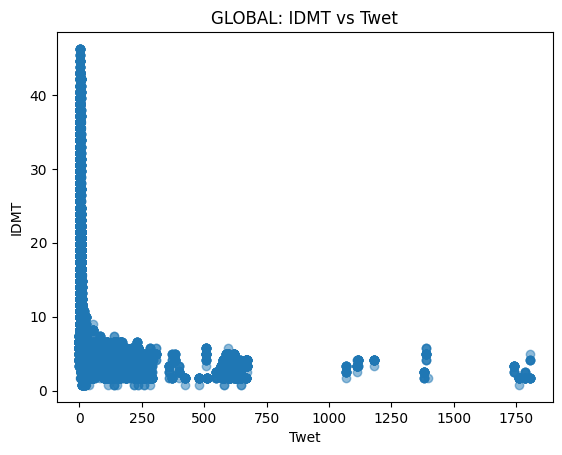

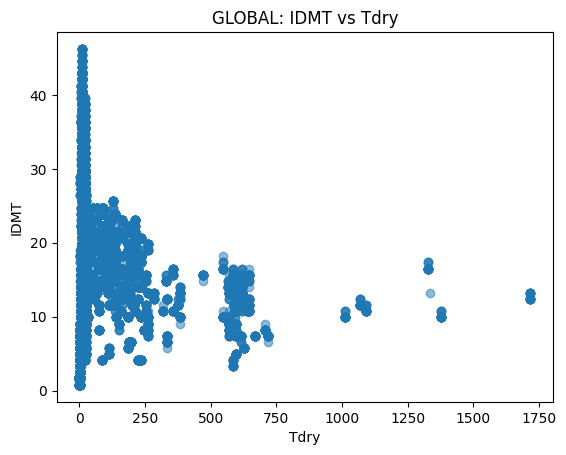

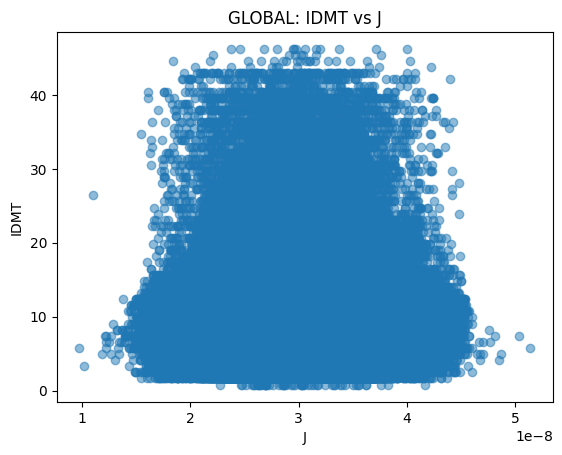

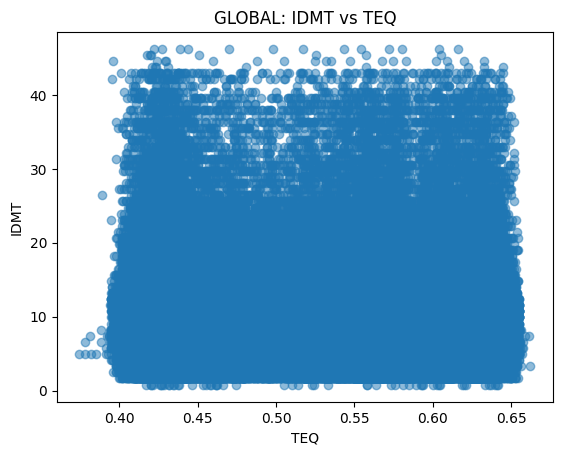

In [10]:
import matplotlib.pyplot as plt

df = df_global.copy()

print("📊 GLOBAL DATASET VISUALIZATION")

# Twet
plt.figure()
plt.scatter(df["Twet"], df["IDMT"], alpha=0.5)
plt.xlabel("Twet")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs Twet")
plt.show()

# Tdry
plt.figure()
plt.scatter(df["Tdry"], df["IDMT"], alpha=0.5)
plt.xlabel("Tdry")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs Tdry")
plt.show()

# J
plt.figure()
plt.scatter(df["J"], df["IDMT"], alpha=0.5)
plt.xlabel("J")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs J")
plt.show()

# TEQ
plt.figure()
plt.scatter(df["TEQ"], df["IDMT"], alpha=0.5)
plt.xlabel("TEQ")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs TEQ")
plt.show()

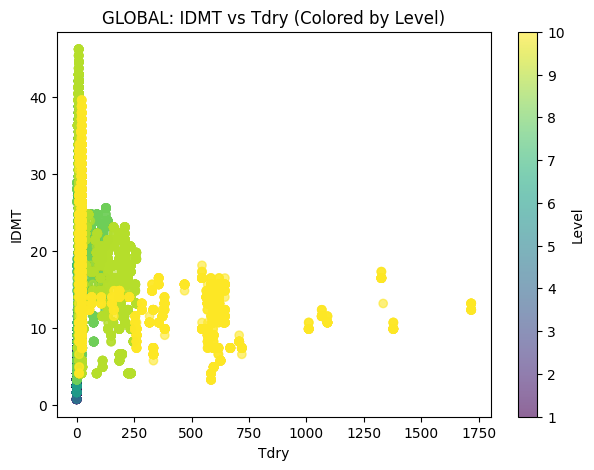

In [11]:
plt.figure(figsize=(7,5))

scatter = plt.scatter(
    df["Tdry"],
    df["IDMT"],
    c=df["Level"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Tdry")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs Tdry (Colored by Level)")

plt.colorbar(scatter, label="Level")

plt.show()

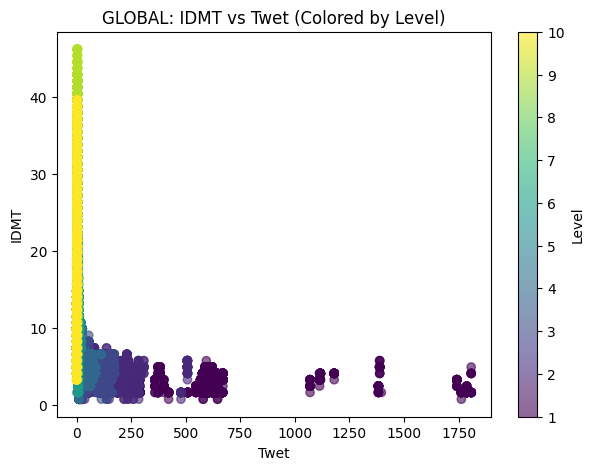

In [12]:
plt.figure(figsize=(7,5))

scatter = plt.scatter(
    df["Twet"],
    df["IDMT"],
    c=df["Level"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Twet")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs Twet (Colored by Level)")

plt.colorbar(scatter, label="Level")

plt.show()

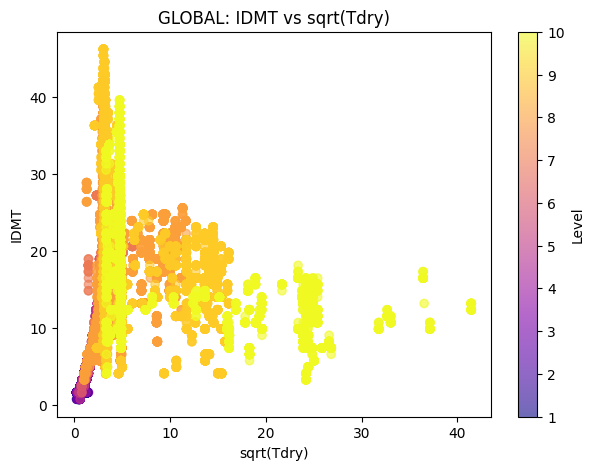

In [13]:
df["sqrt_Tdry"] = np.sqrt(df["Tdry"])
df["sqrt_Twet"] = np.sqrt(df["Twet"])

plt.figure(figsize=(7,5))
plt.scatter(df["sqrt_Tdry"], df["IDMT"], c=df["Level"], cmap="plasma", alpha=0.6)
plt.xlabel("sqrt(Tdry)")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs sqrt(Tdry)")
plt.colorbar(label="Level")
plt.show()

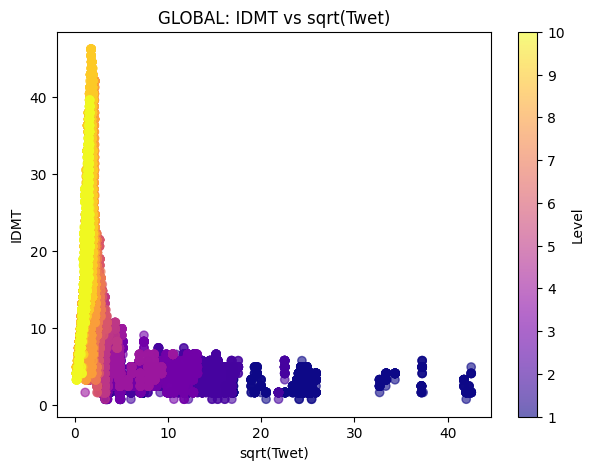

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(df["sqrt_Twet"], df["IDMT"], c=df["Level"], cmap="plasma", alpha=0.6)
plt.xlabel("sqrt(Twet)")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs sqrt(Twet)")
plt.colorbar(label="Level")
plt.show()

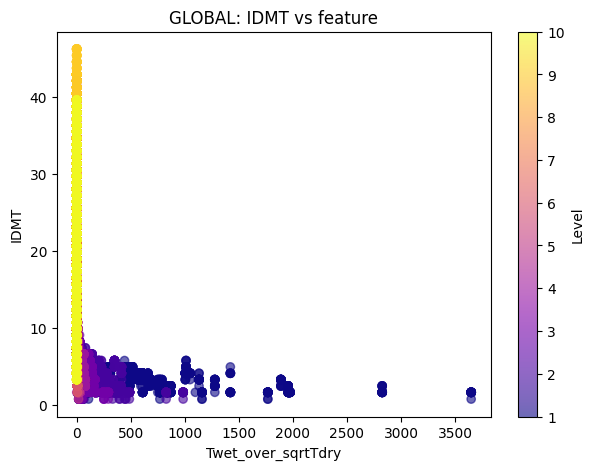

In [15]:
df["Twet_over_sqrtTdry"] = df["Twet"] / np.sqrt(df["Tdry"])

plt.figure(figsize=(7,5))
plt.scatter(df["Twet_over_sqrtTdry"], df["IDMT"], c=df["Level"], cmap="plasma", alpha=0.6)
plt.xlabel("Twet_over_sqrtTdry")
plt.ylabel("IDMT")
plt.title("GLOBAL: IDMT vs feature")
plt.colorbar(label="Level")
plt.show()